<span style="color:green; font-size:300%; font-weight:bold;">DATA SCIENCE INTERNSHIP TASK 2 AT DEVELOPERSHUB CORPORATION</span>

Submitted By: MUHAMMAD FAWAD

Date: 26 JUNE 2026

Email Address: fawaddii7288@gmail.com

---

# <span style="color:yellow; font-size:100%; font-weight:bold;">Task 2: Credit Risk Prediction</span>

## Dataset:
For this task we use Loan Prediction dataset. (Source: Kaggle.com)

## About Dataset:

### - Loan Dataset Introduction

This dataset is widely available on platforms such as Kaggle and is created for educational and predictive analytics purposes. It simulates real-world loan approval scenarios faced by financial institutions.
The Loan Approval Dataset is a financial dataset used to predict whether a loan application should be approved or rejected based on an applicant's personal, financial, and asset-related information. It is commonly used in Machine Learning and Data Science projects for binary classification problems.

The dataset is designed to help banks, financial institutions, and lending organizations assess the creditworthiness of applicants and minimize the risk of loan defaults. By analyzing factors such as income, credit score, assets, employment status, and dependents, predictive models can identify whether an applicant is likely to receive loan approval.

### - Objective

The main objective of this project is to develop a machine learning classification model that predicts whether a loan applicant is likely to receive loan approval based on financial, educational, credit, and asset-related factors.

### - Column Description

- loan_id: Unique identification number assigned to each loan application.
- no_of_dependents: Number of family members financially dependent on the applicant.
- education: Educational qualification of the applicant (Graduate/Not Graduate).
- self_employed: Indicates whether the applicant is self-employed.
- income_annum: Annual income of the applicant.
- loan_amount: Total loan amount requested by the applicant.
- loan_term: Duration of the loan repayment period.
- cibil_score: Credit score representing the applicant's creditworthiness. Higher scores indicate lower lending risk.
- residential_assets_value: Total value of residential properties owned by the applicant.
- commercial_assets_value: Total value of commercial properties owned by the applicant.
- luxury_assets_value: Value of luxury assets such as expensive vehicles, jewelry, etc.
- bank_asset_value: Total value of assets held in bank accounts and investments.
- loan_status: Target variable indicating whether the loan was approved or rejected.

### - Dataset Summary

- Feature Type:	Count
- Total Features:	13
- Numerical Features:	9
- Categorical Features:	3
- Target Variable:	1
- Problem Type:	Binary Classification

### - Overall Conclusion

This project demonstrates how machine learning can assist financial institutions in automating loan approval decisions. Variables such as annual income, CIBIL score, loan amount, and asset values play significant roles in determining loan approval. By training classification models such as Logistic Regression and Decision Tree, lenders can accurately assess applicant risk and make faster, more reliable loan approval decisions.

# 1) Import all necassary libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

- warnings: ignore warnings.
- pandas: Pandas is used for data manipulation and analysis.
- Numpy: Numerical Python.
- matplotlib: Matplotlib is used for plotting graphs and charts.
- Seaborn: Seaborn is used for creating statistical visualizations.
- SimpleImputer: Use for missing data.
- LabelEncoder: Encode the data to convert categorical data into numerical data.
- train_test_split: Split the all data into training part and testing part.
- DecisionTreeClassifier: Model use for classification problem.
- LogisticRegression: Model use for regression problem.
- accuracy_score, confusion_matrix, classification_report: Evaluation metrics.

# 2) Load and view first 3 rows of dataset

In [2]:
data = pd.read_csv('C:\\Users\\khan\\PycharmProjects\\pythonProject3\\loan_approval_dataset.csv')
data.head(3)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected


- data: store dataset in this variable.
- pd.read_csv: read mean display Loan Approval dataset which is in csv (comma separated value) formate.
- head(3): show first 3 rows and if you want last rows use tail instead of head.

# 3) Basic informations about dataset

In [3]:
print("Dataset Shape:")
print(data.shape)

print("\nDataset Info:")
print(data.info())

print("\nStatistical summary:")
data.describe()

Dataset Shape:
(4269, 13)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


missing data
loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64


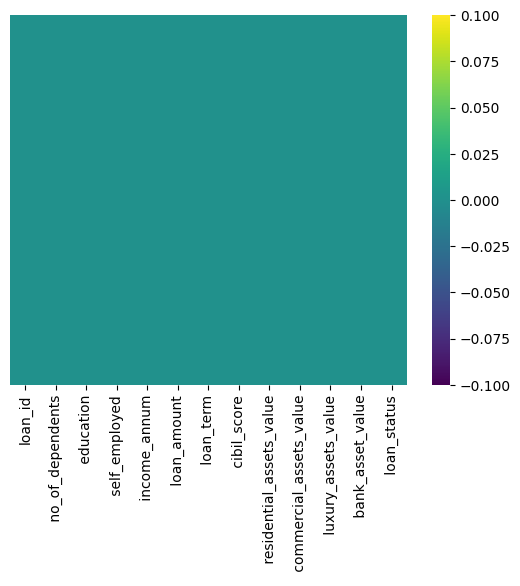

In [4]:
print("missing data")
print(data.isnull().sum().sort_values(ascending=False))

sns.heatmap(data.isnull(), yticklabels=False, cmap='viridis')
plt.show()

- shape: Display all number of rows and columns, So there are 4269 rows and 13 columns.
- Info(): Info is a function which show all basic information like data type and non null values.
- describe(): This function show all statistical informations about rach column.
- isnull().sum(): Check all null values and then sum it, So there is no null value.
- sort_values(ascending=False): This show null values first and not null values last.
- heatmap: show null values graphically.

# 4) EDA & Visualization

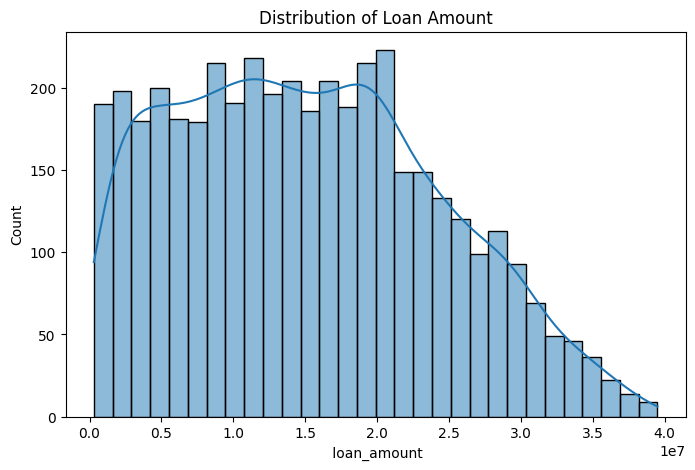

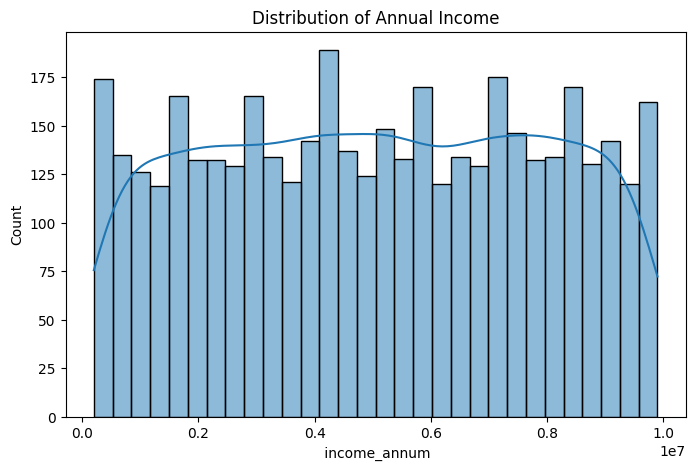

In [5]:
# Loan Amount Distribution

plt.figure(figsize=(8,5))
sns.histplot(data[' loan_amount'], bins=30, kde=True)
plt.title("Distribution of Loan Amount")
plt.show()


# Annual Income Distribution

plt.figure(figsize=(8,5))
sns.histplot(data[' income_annum'], bins=30, kde=True)
plt.title("Distribution of Annual Income")
plt.show()

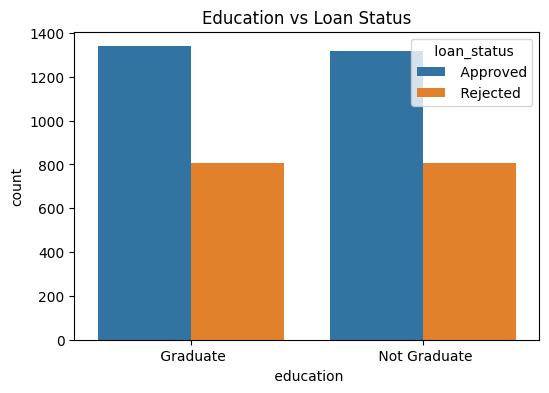

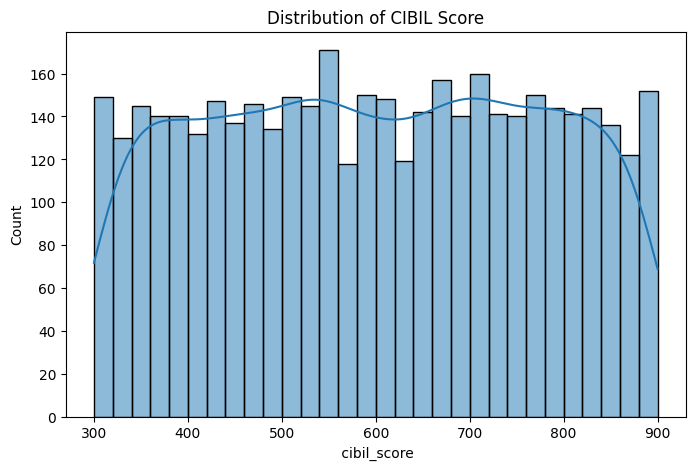

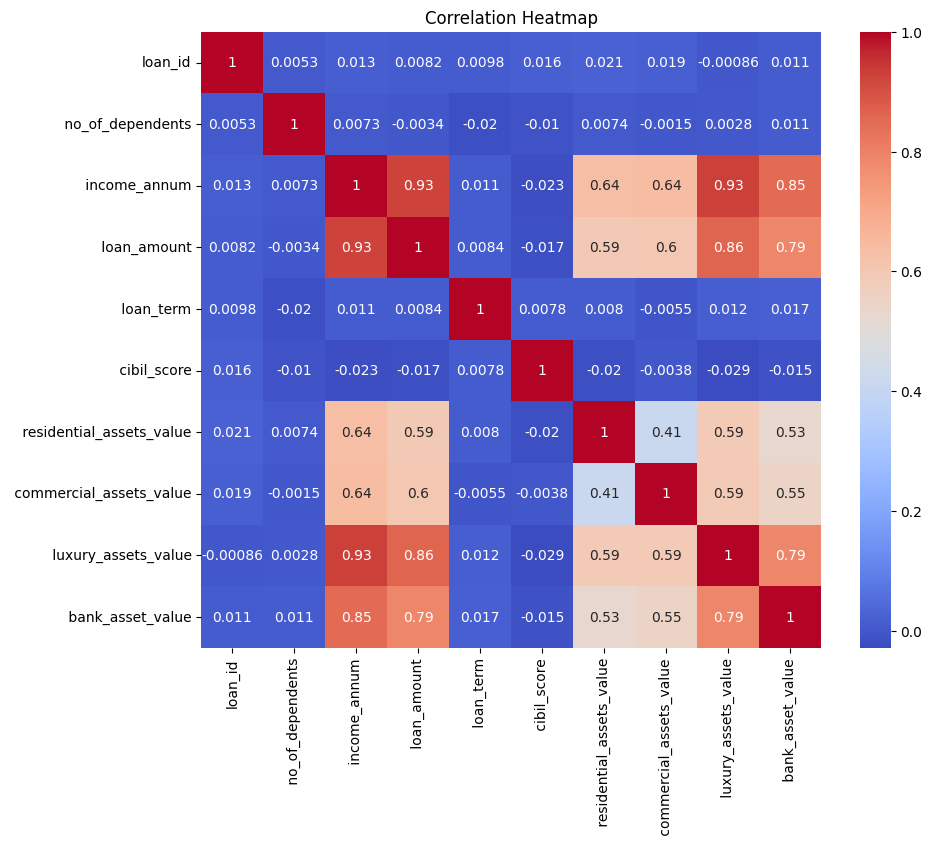

In [6]:
# Education vs Loan Status

plt.figure(figsize=(6,4))
sns.countplot(data=data, x=' education', hue=' loan_status')
plt.title("Education vs Loan Status")
plt.show()


# CIBIL Score Distribution

plt.figure(figsize=(8,5))
sns.histplot(data[' cibil_score'], bins=30, kde=True)
plt.title("Distribution of CIBIL Score")
plt.show()


# Correlation Heatmap

plt.figure(figsize=(10,8))
sns.heatmap(data.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

- Distribution: Above all are non normal because it can not follow a bell curve shape graph.
- Barplot: Show that approval are high than rejected.
- heatmap: Show all numerical columns correlation.

# 5) Encode Categorical Variables

In [7]:
cat_cols = data.select_dtypes(include='object').columns

label_encoder = LabelEncoder()

for col in cat_cols:
    data[col] = label_encoder.fit_transform(data[col])


- cat_cols: We select all categorical columns from data and store in this variable.
- LabelEncoder: Encoder to encode the data.
- fit_transform: Fit encoder on this data and then transform it to new data.

# 6) Feature Selection

In [8]:
X = data.drop([' loan_status', 'loan_id'], axis=1)

y = data[' loan_status']

- X: Take all columns except loan_status and loan_id.
- y: Take only loan_status column.

# 7) Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

- train_test: Split data into training and testing parts.
- train_size: Always give train size greater than test size, I give here 80% data for training and the remaining will for testing. You also use test_size instead of train_size.
- random_state: Only for randomness, if you run again and again our model, So the result will not changing randomly again and again. You also use any other number instead of 42.

# 8) Logistic Regression

In [10]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("\nLOGISTIC REGRESSION RESULTS")

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))


LOGISTIC REGRESSION RESULTS
Accuracy: 0.7985948477751756

Confusion Matrix:
[[488  48]
 [124 194]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.91      0.85       536
           1       0.80      0.61      0.69       318

    accuracy                           0.80       854
   macro avg       0.80      0.76      0.77       854
weighted avg       0.80      0.80      0.79       854



- lr_model: Call the logistic regression model and store in this variable, Maximum iteration i give 1000.
- fit: Fit the model mean train the model on trainig data.
- predict: Test the model prediction on testing data.
- accuracy_score, confusion_matrix and classification_report: All are evaluation metrics, To check model result.

INTERPRETATION:

The Logistic Regression model achieved an accuracy of 79.86%, indicating that approximately 80% of loan applications were classified correctly.

Confusion Matrix Analysis:
- 488 applicants were correctly predicted as Class 0.
- 194 applicants were correctly predicted as Class 1.
- 48 applicants were incorrectly predicted as Class 1.
- 124 applicants were incorrectly predicted as Class 0.

Classification Report Analysis:
- Precision (Class 0): 0.80
    80% of predicted Class 0 cases were actually Class 0.
- Recall (Class 0): 0.91
    The model successfully identified 91% of all actual Class 0 cases.
- Precision (Class 1): 0.80
    80% of predicted Class 1 cases were correct.
- Recall (Class 1): 0.61
    The model identified only 61% of actual Class 1 cases, meaning many Class 1 applicants were missed.

# 9) Decision Tree Classifier

In [11]:
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("\nDECISION TREE RESULTS")

print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))


DECISION TREE RESULTS
Accuracy: 0.968384074941452

Confusion Matrix:
[[516  20]
 [  7 311]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97       536
           1       0.94      0.98      0.96       318

    accuracy                           0.97       854
   macro avg       0.96      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854



- dt_model: Call the decision tree classifier model and store in this variable, Max_depth i give 5 and random state i already discuss in train test split part.
- fit: Fit the model mean train the model on trainig data.
- predict: Test the model prediction on testing data.
- accuracy_score, confusion_matrix and classification_report: All are evaluation metrics, To check model result.

INTERPRETATION:

The Decision Tree model achieved an accuracy of 96.84%, indicating excellent predictive performance.

Confusion Matrix Analysis:
- 516 applicants were correctly predicted as Class 0.
- 311 applicants were correctly predicted as Class 1.
- 20 applicants were incorrectly predicted as Class 1.
- 7 applicants were incorrectly predicted as Class 0.

Classification Report Analysis:

Class 0
- Precision = 0.99
- Recall = 0.96
- F1-Score = 0.97

Class 1
- Precision = 0.94
- Recall = 0.98
- F1-Score = 0.96

# 10) Compare Models

In [12]:
lr_acc = accuracy_score(y_test, y_pred_lr)
dt_acc = accuracy_score(y_test, y_pred_dt)

print("\nModel Comparison")
print("Logistic Regression Accuracy:", lr_acc)
print("Decision Tree Accuracy:", dt_acc)


Model Comparison
Logistic Regression Accuracy: 0.7985948477751756
Decision Tree Accuracy: 0.968384074941452


- lr_acc: logistic regression accuracy score.
- dt_acc: decision tree classifier accuracy score.

Comparison Analysis:

- The Decision Tree model outperformed Logistic Regression in every evaluation metric.
- Logistic Regression correctly classified about 80% of applicants, whereas Decision Tree correctly classified nearly 97%.
- Decision Tree achieved much higher recall for Class 1 (98% vs 61%), meaning it identified significantly more positive cases.
- The confusion matrix shows that Decision Tree produced only 27 total errors, compared to 172 errors made by Logistic Regression.
- Decision Tree captured complex relationships between applicant income, assets, credit score, and loan approval more effectively than Logistic Regression.

OVERALL CONCLUSION:

The objective of this project was to predict whether a loan applicant would be approved or rejected based on financial and personal attributes. Two classification algorithms, Logistic Regression and Decision Tree, were trained and evaluated.

Among the two models, the Decision Tree classifier achieved the best performance with an accuracy of 96.84%, significantly outperforming Logistic Regression, which achieved 79.86% accuracy. The Decision Tree model also produced higher precision, recall, and F1-scores while making fewer prediction errors.

Therefore, the Decision Tree model is the preferred model for this Loan Approval Prediction system, as it provides more accurate and reliable predictions for determining whether a loan applicant is likely to be approved or rejected.

                                                            END OF TASK 2                                                           

---